# Lab 2: Building an Analytical Base Table for Machine Learning
**Prepared by:** Pranamya Sharma
**LinkedIn:** [https://www.linkedin.com/in/pranamya-sharma-425149321/]

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
REPORTS_DIR = Path("../reports")
FIGURES_DIR = Path("../figures")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
for file in DATA_DIR.glob("*.csv"):
    print(file.name)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [4]:
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

In [5]:
tables = {
    "orders": orders,
    "customers": customers,
    "reviews": reviews,
    "payments": payments,
    "order_items": order_items,
    "products": products,
    "category_translation": category_translation
}

for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

orders: 99441 rows, 8 columns
customers: 99441 rows, 5 columns
reviews: 99224 rows, 7 columns
payments: 103886 rows, 5 columns
order_items: 112650 rows, 7 columns
products: 32951 rows, 9 columns
category_translation: 71 rows, 2 columns


In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [8]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [9]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [10]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [11]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [12]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [13]:
orders[date_columns].info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       99441 non-null  datetime64[us]
 1   order_approved_at              99281 non-null  datetime64[us]
 2   order_delivered_carrier_date   97658 non-null  datetime64[us]
 3   order_delivered_customer_date  96476 non-null  datetime64[us]
 4   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5)
memory usage: 3.8 MB


In [14]:
orders["order_year"] = orders["order_purchase_timestamp"].dt.year
orders["order_month"] = orders["order_purchase_timestamp"].dt.month
orders["order_day"] = orders["order_purchase_timestamp"].dt.day
orders["order_day_of_week"] = orders["order_purchase_timestamp"].dt.dayofweek
orders["order_hour"] = orders["order_purchase_timestamp"].dt.hour

In [15]:
orders[[
    "order_purchase_timestamp",
    "order_year",
    "order_month",
    "order_day",
    "order_day_of_week",
    "order_hour"
]].head()

,order_purchase_timestamp,order_year,order_month,order_day,order_day_of_week,order_hour
0,2017-10-02 10:56:33,2017,10,2,0,10
1,2018-07-24 20:41:37,2018,7,24,1,20
2,2018-08-08 08:38:49,2018,8,8,2,8
3,2017-11-18 19:28:06,2017,11,18,5,19
4,2018-02-13 21:18:39,2018,2,13,1,21


In [16]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

orders["estimated_delivery_days"] = (
    orders["order_estimated_delivery_date"] -
    orders["order_purchase_timestamp"]
).dt.days

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_estimated_delivery_date"]
).dt.days

In [17]:
orders["is_late_delivery"] = np.where(
    orders["delivery_delay_days"] > 0,
    1,
    0
)

In [18]:
orders[[
    "order_id",
    "order_status",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late_delivery"
]].head()

,order_id,order_status,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,8.0,15,-8.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,13.0,19,-6.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,9.0,26,-18.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,13.0,26,-13.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2.0,12,-10.0,0


In [19]:
orders["is_late_delivery"].value_counts()

is_late_delivery
0    92906
1     6535
Name: count, dtype: int64

In [20]:
orders["is_late_delivery"].value_counts(normalize=True) * 100

is_late_delivery
0    93.428264
1     6.571736
Name: proportion, dtype: float64

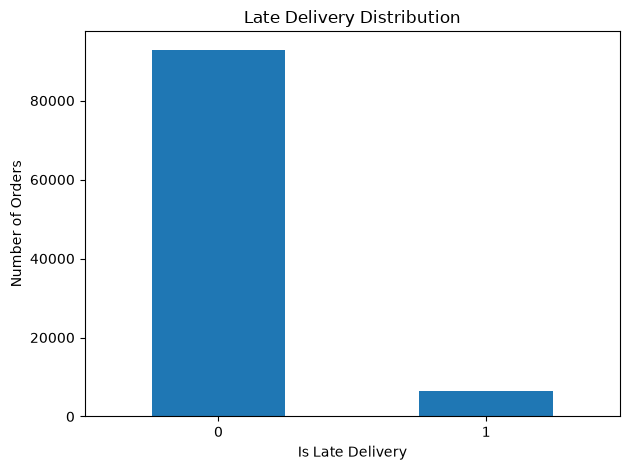

In [21]:
orders["is_late_delivery"].value_counts().plot(kind="bar")
plt.title("Late Delivery Distribution")
plt.xlabel("Is Late Delivery")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab02_late_delivery_distribution.png")
plt.show()

In [22]:
payment_features = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    max_payment_installments=("payment_installments", "max"),
    payment_types_count=("payment_type", "nunique")
).reset_index()

payment_features.head()

,order_id,total_payment_value,max_payment_installments,payment_types_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1


In [23]:
dominant_payment_type = payments.groupby("order_id")["payment_type"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).reset_index()

dominant_payment_type = dominant_payment_type.rename(
    columns={"payment_type": "dominant_payment_type"}
)

payment_features = payment_features.merge(
    dominant_payment_type,
    on="order_id",
    how="left"
)

In [24]:
item_features = order_items.groupby("order_id").agg(
    total_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    unique_products=("product_id", "nunique"),
    unique_sellers=("seller_id", "nunique")
).reset_index()

item_features.head()

,order_id,total_items,total_price,total_freight,unique_products,unique_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,1,1
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,1,1


In [25]:
items_products = order_items.merge(
    products,
    on="product_id",
    how="left"
)

items_products = items_products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

items_products[[
    "order_id",
    "product_id",
    "product_category_name",
    "product_category_name_english"
]].head()

,order_id,product_id,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,garden_tools


In [26]:
order_category = items_products.groupby("order_id").agg(
    main_product_category=(
        "product_category_name_english",
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
).reset_index()

order_category.head()

,order_id,main_product_category
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop
2,000229ec398224ef6ca0657da4fc703e,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools


In [27]:
review_features = reviews.groupby("order_id").agg(
    review_score=("review_score", "mean"),
    review_comment_count=("review_comment_message", lambda x: x.notnull().sum()),
    has_review_comment=("review_comment_message", lambda x: int(x.notnull().any()))
).reset_index()

review_features.head()

,order_id,review_score,review_comment_count,has_review_comment
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,0,0
2,000229ec398224ef6ca0657da4fc703e,5.0,1,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,0,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1,1


In [28]:
abt = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

abt = abt.merge(
    review_features,
    on="order_id",
    how="left"
)

abt = abt.merge(
    payment_features,
    on="order_id",
    how="left"
)

abt = abt.merge(
    item_features,
    on="order_id",
    how="left"
)

abt = abt.merge(
    order_category,
    on="order_id",
    how="left"
)

abt.shape

(99441, 34)

In [29]:
abt["is_low_review"] = np.where(
    abt["review_score"] <= 2,
    1,
    0
)

In [30]:
abt["is_low_review"].value_counts()

is_low_review
0    84992
1    14449
Name: count, dtype: int64

In [31]:
abt["is_low_review"].value_counts(normalize=True) * 100

is_low_review
0    85.469776
1    14.530224
Name: proportion, dtype: float64

In [32]:
selected_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "customer_city",
    "customer_state",
    "order_status",
    "order_year",
    "order_month",
    "order_day",
    "order_day_of_week",
    "order_hour",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late_delivery",
    "review_score",
    "is_low_review",
    "review_comment_count",
    "has_review_comment",
    "total_payment_value",
    "max_payment_installments",
    "payment_types_count",
    "dominant_payment_type",
    "total_items",
    "total_price",
    "total_freight",
    "unique_products",
    "unique_sellers",
    "main_product_category"
]

abt = abt[selected_columns]
abt.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,is_low_review,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,10,8.0,15,-8.0,0,4.0,0,1.0,1.0,38.71,1.0,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,20,13.0,19,-6.0,0,4.0,0,1.0,1.0,141.46,1.0,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,8,9.0,26,-18.0,0,5.0,0,0.0,0.0,179.12,3.0,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,19,13.0,26,-13.0,0,5.0,0,1.0,1.0,72.20,1.0,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,21,2.0,12,-10.0,0,5.0,0,0.0,0.0,28.62,1.0,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [33]:
abt.shape

(99441, 29)

In [34]:
abt.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  99441 non-null  str    
 1   customer_id               99441 non-null  str    
 2   customer_unique_id        99441 non-null  str    
 3   customer_city             99441 non-null  str    
 4   customer_state            99441 non-null  str    
 5   order_status              99441 non-null  str    
 6   order_year                99441 non-null  int32  
 7   order_month               99441 non-null  int32  
 8   order_day                 99441 non-null  int32  
 9   order_day_of_week         99441 non-null  int32  
 10  order_hour                99441 non-null  int32  
 11  delivery_days             96476 non-null  float64
 12  estimated_delivery_days   99441 non-null  int64  
 13  delivery_delay_days       96476 non-null  float64
 14  is_late_delivery 

In [35]:
abt.isnull().sum().sort_values(ascending=False)

delivery_days               2965
delivery_delay_days         2965
main_product_category       2185
total_freight                775
unique_sellers               775
unique_products              775
total_price                  775
total_items                  775
review_score                 768
has_review_comment           768
review_comment_count         768
total_payment_value            1
max_payment_installments       1
payment_types_count            1
dominant_payment_type          1
order_day_of_week              0
order_day                      0
estimated_delivery_days        0
order_hour                     0
order_status                   0
customer_state                 0
order_id                       0
customer_city                  0
customer_unique_id             0
customer_id                    0
order_year                     0
order_month                    0
is_late_delivery               0
is_low_review                  0
dtype: int64

In [36]:
abt["order_id"].duplicated().sum()

np.int64(0)

In [37]:
abt_summary = pd.DataFrame({
    "column": abt.columns,
    "data_type": abt.dtypes.astype(str).values,
    "missing_count": abt.isnull().sum().values,
    "missing_percent": (abt.isnull().sum().values / len(abt)) * 100,
    "unique_values": [abt[col].nunique() for col in abt.columns]
})

abt_summary

,column,data_type,missing_count,missing_percent,unique_values
0,order_id,str,0,0.000000,99441
1,customer_id,str,0,0.000000,99441
2,customer_unique_id,str,0,0.000000,96096
3,customer_city,str,0,0.000000,4119
4,customer_state,str,0,0.000000,27
5,order_status,str,0,0.000000,8
6,order_year,int32,0,0.000000,3
7,order_month,int32,0,0.000000,12
8,order_day,int32,0,0.000000,31
9,order_day_of_week,int32,0,0.000000,7


In [38]:
abt_summary.to_csv(
    REPORTS_DIR / "lab02_abt_summary.csv",
    index=False
)

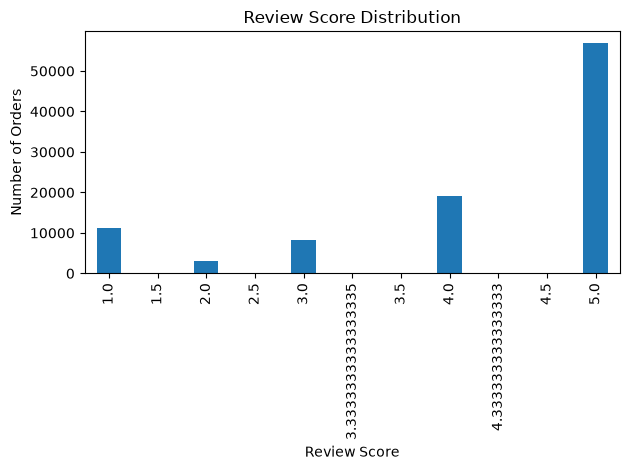

In [39]:
abt["review_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab02_review_score_distribution.png")
plt.show()

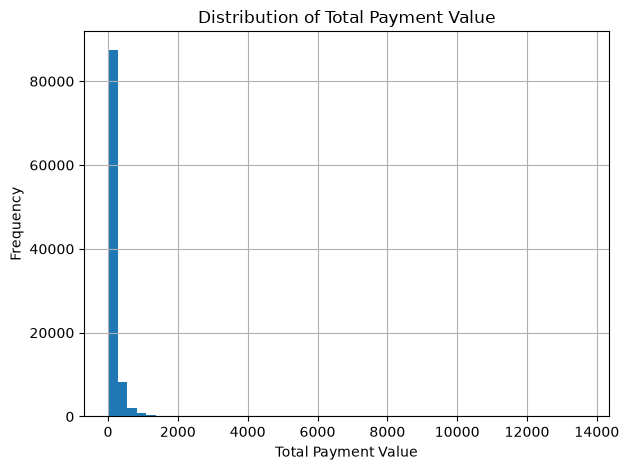

In [40]:
abt["total_payment_value"].hist(bins=50)
plt.title("Distribution of Total Payment Value")
plt.xlabel("Total Payment Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab02_payment_value_distribution.png")
plt.show()

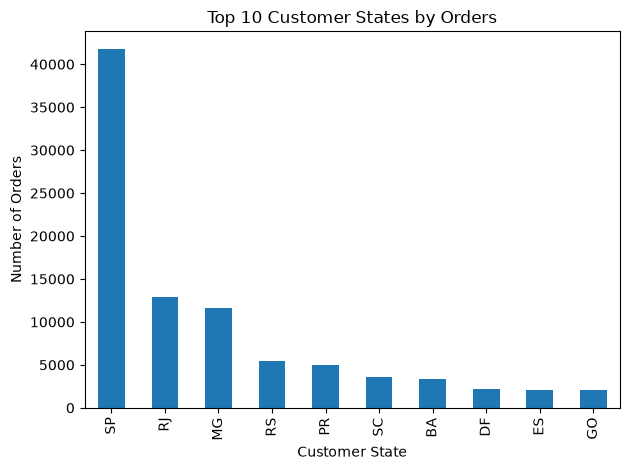

In [41]:
abt["customer_state"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Customer States by Orders")
plt.xlabel("Customer State")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab02_top_customer_states.png")
plt.show()

In [42]:
abt.to_csv(
    PROCESSED_DIR / "olist_orders_abt.csv",
    index=False
)

In [43]:
(PROCESSED_DIR / "olist_orders_abt.csv").exists()

True

In [44]:
abt_check = pd.read_csv(PROCESSED_DIR / "olist_orders_abt.csv")
abt_check.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,is_low_review,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,10,8.0,15,-8.0,0,4.0,0,1.0,1.0,38.71,1.0,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,20,13.0,19,-6.0,0,4.0,0,1.0,1.0,141.46,1.0,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,8,9.0,26,-18.0,0,5.0,0,0.0,0.0,179.12,3.0,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,19,13.0,26,-13.0,0,5.0,0,1.0,1.0,72.20,1.0,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,21,2.0,12,-10.0,0,5.0,0,0.0,0.0,28.62,1.0,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [45]:
monthly_orders = abt.groupby(["order_year", "order_month"]).agg(
    order_count=("order_id", "count"),
    total_revenue=("total_payment_value", "sum")
).reset_index()

monthly_orders.head()

,order_year,order_month,order_count,total_revenue
0,2016,9,4,252.24
1,2016,10,324,59090.48
2,2016,12,1,19.62
3,2017,1,800,138488.04
4,2017,2,1780,291908.01


In [46]:
avg_review_by_state = abt.groupby("customer_state").agg(
    avg_review_score=("review_score", "mean"),
    order_count=("order_id", "count")
).reset_index()

avg_review_by_state.sort_values(
    by="avg_review_score",
    ascending=False
).head()

,customer_state,avg_review_score,order_count
2,AM,4.205479,148
3,AP,4.194030,68
17,PR,4.181112,5045
25,SP,4.174126,41746
10,MG,4.135754,11635


In [47]:
late_delivery_by_category = abt.groupby("main_product_category").agg(
    late_delivery_rate=("is_late_delivery", "mean"),
    order_count=("order_id", "count")
).reset_index()

late_delivery_by_category.sort_values(
    by="late_delivery_rate",
    ascending=False
).head()

,main_product_category,late_delivery_rate,order_count
41,furniture_mattress_and_upholstery,0.131579,38
46,home_comfort_2,0.130435,23
4,audio,0.117143,350
47,home_confort,0.099715,351
33,fashion_underwear_beach,0.090909,121


Conceptual Questions:

1. What is an Analytical Base Table?
It's a single, clean table built from many raw data tables, where each row is one example (here, one order) and each column is a feature. It's the table you actually feed into a machine learning model.

2. Why did we choose one row per order for this lab?
Because we want to build features and predictions about orders (like "was this order late?" or "did this order get a bad review?"). To do that, every order needs to be exactly one row, so the model can learn patterns per order.

3. Why should we aggregate payments before merging with orders?
Because one order can have multiple payment rows (e.g., paid in installments). If we merged this table directly, each order would get duplicated once for every payment row it has, breaking our "one row per order" rule. Aggregating first (like summing total payment value) squashes it back to one row per order.

4. Why should we aggregate order_items before merging with orders?
Same reason — one order can contain multiple products/items, so order_items has multiple rows per order. We aggregate it first (total items, total price, etc.) so each order still ends up as just one row after merging.

5. What can go wrong if we directly merge one-to-many tables without aggregation?
The number of rows in our final table would increase — one order could become 2, 3, or more rows. This creates duplicate/incorrect data, messes up counts and averages, and makes the dataset unusable for ML since it no longer follows "one row = one order."

6. Which feature may help predict late delivery?
estimated_delivery_days (how long delivery was expected to take) — orders with a very short estimated delivery window are more likely to end up late.

7. Which feature may help predict low review score?
delivery_delay_days — customers whose orders arrived late are more likely to leave a bad review.

8. What is the difference between review_score and is_low_review?
review_score is the actual rating a customer gave (usually 1 to 5). is_low_review is a simplified yes/no version of it — 1 if the score was 2 or below, 0 otherwise. It turns a rating into a simple target for classification.

9. Why is is_late_delivery a classification target?
Because it only has two possible values — 0 (not late) or 1 (late). Predicting between two fixed categories like this is called classification, as opposed to predicting a continuous number (which would be regression).

10. Which columns should not be used directly as ML features? Why?
Columns like order_id, customer_id, and customer_unique_id shouldn't be used as features. They're just unique identifiers with no real pattern or meaning — a model can't learn anything useful from them, and using them could cause the model to "memorize" specific IDs instead of learning general patterns.

Ques How does building an Analytical Base Table help convert business data into
Machine Learning-ready data?  
Ans: Real-world business data usually exists as raw data spread across many separate tables — customers, orders, payments, reviews, and products — that are connected through table relationships like customer_id, order_id, and product_id. On its own, this raw, scattered data isn't usable by a Machine Learning model, since models need a single clean table with one row per example. Building an Analytical Base Table solves this by joining all these related tables into one order-level table, while carefully aggregating any table that has multiple rows per order (like payments or items) so nothing gets duplicated. Along the way, we perform feature creation — turning raw dates and amounts into meaningful columns like delivery duration, delivery delay, and total payment value, which give the model useful signals to learn from. We also define target variables such as is_late_delivery and is_low_review, which represent the outcomes we eventually want the model to predict. By the end of this process, the messy, relational business data has been transformed into a clean, structured dataset that is fully ready for future model training, feature engineering, and experimentation with different Machine Learning algorithms.

In [48]:
required_files = [
    "olist_customers_dataset.csv",
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_products_dataset.csv",
    "product_category_name_translation.csv"
]

for f in required_files:
    print(f, "->", (DATA_DIR / f).exists())

olist_customers_dataset.csv -> True
olist_orders_dataset.csv -> True
olist_order_items_dataset.csv -> True
olist_order_payments_dataset.csv -> True
olist_order_reviews_dataset.csv -> True
olist_products_dataset.csv -> True
product_category_name_translation.csv -> True


In [49]:
orders[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [50]:
print("Original payments rows:", payments.shape[0])
print("Aggregated payment_features rows:", payment_features.shape[0])
print("Unique order_ids in payments:", payments["order_id"].nunique())

Original payments rows: 103886
Aggregated payment_features rows: 99440
Unique order_ids in payments: 99440


In [51]:
print("Original order_items rows:", order_items.shape[0])
print("Aggregated item_features rows:", item_features.shape[0])
print("Unique order_ids in order_items:", order_items["order_id"].nunique())

Original order_items rows: 112650
Aggregated item_features rows: 98666
Unique order_ids in order_items: 98666
